
# Notebook 2 — Dynamic Programming: Policy Iteration & Value Iteration

### Recap

In notebook 1 we derived the **Bellman expectation equation**

$$
V^\pi(s) = \sum_{a} \pi(a \mid s) \sum_{s'} P(s' \mid s, a) \Big[ R(s,a,s') + \gamma V^\pi(s') \Big]
$$

and the **Bellman optimality equation**

$$
V^*(s) = \max_a \sum_{s'} P(s' \mid s, a) \Big[ R(s,a,s') + \gamma V^*(s') \Big]
$$

and we *solved* the first one exactly, for a fixed policy, using linear algebra.
But we never answered the actually-interesting question: **what is the best
possible policy, and how do we find it?** That's this notebook's job.

### What this notebook covers

- Why "Dynamic Programming" is the right name for what we're about to do —
  and what it assumes (full knowledge of $P$ and $R$).
- **Policy Evaluation**: turning the Bellman expectation equation into an
  iterative algorithm, and understanding *why* it's guaranteed to converge.
- **Policy Improvement**: a theorem that lets us turn any policy into a
  strictly-better one just by being greedy with respect to its own value
  function.
- **Policy Iteration**: alternate evaluation and improvement to reach the
  optimum, visualized step by step.
- **Value Iteration**: a leaner algorithm that merges evaluation and
  improvement into a single sweep — derived directly from the Bellman
  *optimality* equation.
- **Generalized Policy Iteration (GPI)**: the one-sentence idea that secretly
  unifies *every* algorithm in this entire course, including PPO and GRPO.
- Why none of this can be run directly on an LLM — and exactly what has to
  change, which sets up notebook 3.



## 1. What "Dynamic Programming" actually means here

"Dynamic Programming" (DP) is a general algorithm-design idea: if a problem can
be broken into overlapping subproblems, and you can express the solution to the
whole problem recursively in terms of solutions to smaller subproblems, then
you can solve it efficiently by solving each subproblem once and reusing the
answer (instead of recomputing it exponentially many times).

Look back at the Bellman equation. $V^\pi(s)$ is defined *in terms of*
$V^\pi(s')$ for neighboring states $s'$ — that recursive structure **is** the
overlapping-subproblem structure DP needs. So "solving the Bellman equation" and
"dynamic programming" are, in this context, the same activity viewed from two
angles.

There is one crucial assumption baked into every algorithm in this notebook:
**we assume the transition function $P(s'\mid s,a)$ and reward function
$R(s,a,s')$ are fully known in advance.** Because of this, DP is sometimes
called *planning* rather than *learning* — there's no trial-and-error, no
interaction with an unknown environment, no data collection at all. We're just
doing exact computation on a model we already have in hand. This assumption is
what makes exact computation possible, and it's also exactly the assumption
we'll have to drop in notebook 3 to get something that works on problems (like
LLMs) where nobody hands you $P$ and $R$ as a lookup table.


In [ ]:

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

class GridWorld:
    """Same GridWorld as notebook 1 -- kept self-contained here on purpose,
    so this notebook can be read and run independently."""

    ACTIONS = ["up", "down", "left", "right"]
    ACTION_DELTAS = {
        "up": (-1, 0), "down": (1, 0), "left": (0, -1), "right": (0, 1),
    }
    ARROWS = {"up": "↑", "down": "↓", "left": "←", "right": "→"}

    def __init__(self, height=4, width=4, start=(0, 0), goal=(3, 3), pit=(1, 2),
                 step_reward=-1.0, goal_reward=10.0, pit_reward=-10.0, gamma=0.95):
        self.height, self.width = height, width
        self.start, self.goal, self.pit = start, goal, pit
        self.step_reward, self.goal_reward, self.pit_reward = step_reward, goal_reward, pit_reward
        self.gamma = gamma
        self.n_states = height * width
        self.n_actions = len(self.ACTIONS)
        self.all_states = [(r, c) for r in range(height) for c in range(width)]

    def is_terminal(self, rc):
        return rc == self.goal or rc == self.pit

    def step(self, rc, action):
        if self.is_terminal(rc):
            raise ValueError("Cannot step from a terminal state.")
        dr, dc = self.ACTION_DELTAS[action]
        r, c = rc[0] + dr, rc[1] + dc
        if not (0 <= r < self.height and 0 <= c < self.width):
            r, c = rc
        next_rc = (r, c)
        if next_rc == self.goal:
            reward = self.goal_reward
        elif next_rc == self.pit:
            reward = self.pit_reward
        else:
            reward = self.step_reward
        return next_rc, reward, self.is_terminal(next_rc)

    def render(self):
        grid = [["." for _ in range(self.width)] for _ in range(self.height)]
        gr, gc = self.goal; pr, pc = self.pit
        grid[gr][gc] = "G"
        grid[pr][pc] = "P"
        print("\n".join(" ".join(row) for row in grid))

env = GridWorld()
print("GridWorld layout (G=goal, P=pit):")
env.render()

def plot_value_grid(env, V, title, ax=None):
    grid = np.array([[V.get((r, c), 0.0) for c in range(env.width)] for r in range(env.height)])
    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=(4.5, 4.5))
    im = ax.imshow(grid, cmap="RdYlGn")
    for r in range(env.height):
        for c in range(env.width):
            ax.text(c, r, f"{grid[r,c]:.1f}", ha="center", va="center")
    ax.set_title(title)
    if own_fig:
        plt.colorbar(im)
        plt.show()

def plot_policy_grid(env, policy_probs, title, ax=None):
    """Deterministic-policy visualization: draw the arrow of whichever action
    has the highest probability in each state."""
    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=(4.5, 4.5))
    ax.imshow(np.zeros((env.height, env.width)), cmap="Greys", vmin=0, vmax=1)
    for r in range(env.height):
        for c in range(env.width):
            s = (r, c)
            if s == env.goal:
                label = "G"
            elif s == env.pit:
                label = "P"
            else:
                best_a = max(policy_probs[s], key=policy_probs[s].get)
                label = GridWorld.ARROWS[best_a]
            ax.text(c, r, label, ha="center", va="center", fontsize=16)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(title)
    if own_fig:
        plt.show()


GridWorld layout (G=goal, P=pit):
. . . .
. . P .
. . . .
. . . G



## 2. Policy Evaluation: the Bellman equation as an iterative algorithm

Notebook 1 solved $V^\pi = R^\pi + \gamma P^\pi V^\pi$ exactly with
`np.linalg.solve`. That's elegant, but it doesn't generalize well (matrix
inversion is $O(n^3)$, and later we'll want update rules that generalize to
function approximation). There's a second way to solve the exact same
equation, using nothing but repeated substitution.

Define the **Bellman expectation operator** $T^\pi$, which takes any value
function $V$ and produces a new one:

$$
(T^\pi V)(s) = \sum_a \pi(a\mid s) \sum_{s'} P(s'\mid s,a)\big[R(s,a,s') + \gamma V(s')\big]
$$

By definition, $V^\pi$ is the (unique) **fixed point** of this operator:
$T^\pi V^\pi = V^\pi$. That immediately suggests an algorithm: start from any
guess $V_0$ (e.g. all zeros) and just keep applying the operator —

$$
V_{k+1} = T^\pi V_k
$$

— hoping it settles down to $V^\pi$. This is **iterative policy evaluation**.

**Why does this actually converge?** Here's the one-paragraph argument.
$T^\pi$ is a **$\gamma$-contraction** in the max-norm: for any two value
functions $V_1, V_2$,

$$
\max_s \big| (T^\pi V_1)(s) - (T^\pi V_2)(s) \big| \;\le\; \gamma \max_{s'} |V_1(s') - V_2(s')|
$$

Why? $(T^\pi V_1)(s) - (T^\pi V_2)(s)$ is a *weighted average* (over actions and
next-states, with the transition/policy probabilities as weights) of
$\gamma\big(V_1(s') - V_2(s')\big)$ terms. A weighted average of numbers can
never exceed the largest one in magnitude — so the difference is bounded by
$\gamma$ times the single largest disagreement between $V_1$ and $V_2$
anywhere. Apply $T^\pi$ again and the *worst-case* gap shrinks by another
factor of $\gamma$. Repeat forever and the gap shrinks geometrically to zero —
this is exactly the Banach fixed-point theorem, and it holds for *any* starting
$V_0$, which is why we're allowed to start from all zeros with no risk of
converging to the wrong answer.


Converged after 163 sweeps.


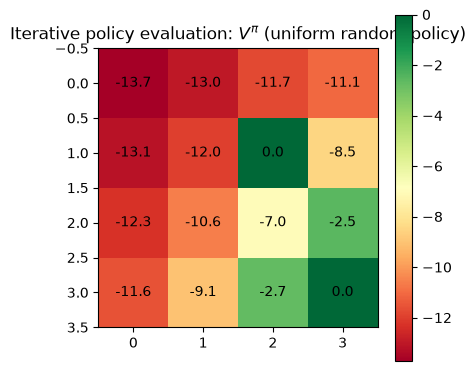

In [2]:

def iterative_policy_evaluation(env, policy_probs, gamma, theta=1e-8, max_sweeps=10000):
    """
    Repeatedly apply the Bellman expectation operator T^pi until the
    largest change in any state's value drops below theta.
    Returns the converged V, and the per-sweep max-delta history (this
    history is exactly what lets us SEE the geometric (gamma-rate) shrinkage
    the contraction argument above promises).
    """
    V = {s: 0.0 for s in env.all_states}
    history = []
    for sweep in range(max_sweeps):
        delta = 0.0
        V_new = {}
        for s in env.all_states:
            if env.is_terminal(s):
                V_new[s] = 0.0
                continue
            v = 0.0
            for a, p_a in policy_probs[s].items():
                if p_a == 0.0:
                    continue
                s_next, reward, _ = env.step(s, a)
                v += p_a * (reward + gamma * V[s_next])
            V_new[s] = v
            delta = max(delta, abs(V_new[s] - V[s]))
        V = V_new
        history.append(delta)
        if delta < theta:
            break
    return V, history

uniform_probs = {s: {a: 0.25 for a in GridWorld.ACTIONS} for s in env.all_states}
V_pi, delta_history = iterative_policy_evaluation(env, uniform_probs, env.gamma)

print(f"Converged after {len(delta_history)} sweeps.")
plot_value_grid(env, V_pi, "Iterative policy evaluation: $V^\\pi$ (uniform random policy)")


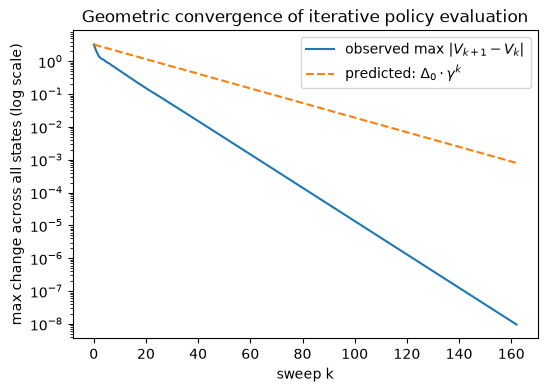

In [3]:

# Confirm the contraction argument empirically: on a log-scale y-axis, the
# max-delta per sweep should look like a straight line with slope log(gamma).
fig, ax = plt.subplots(figsize=(6, 4))
ax.semilogy(delta_history, label="observed max $|V_{k+1}-V_k|$")
predicted = delta_history[0] * (env.gamma ** np.arange(len(delta_history)))
ax.semilogy(predicted, "--", label=r"predicted: $\Delta_0 \cdot \gamma^k$")
ax.set_xlabel("sweep k")
ax.set_ylabel("max change across all states (log scale)")
ax.set_title("Geometric convergence of iterative policy evaluation")
ax.legend()
plt.show()


In [4]:

# Sanity check against notebook 1's exact linear-algebra solution -- same
# policy, same MDP, two completely different computational routes.
def build_bellman_system(env, policy_probs):
    n = env.n_states
    idx_of = {s: i for i, s in enumerate(env.all_states)}
    P_pi = np.zeros((n, n))
    R_pi = np.zeros(n)
    for s in env.all_states:
        i = idx_of[s]
        if env.is_terminal(s):
            P_pi[i, i] = 1.0
            continue
        for a, p_a in policy_probs[s].items():
            if p_a == 0.0:
                continue
            s_next, reward, _ = env.step(s, a)
            j = idx_of[s_next]
            P_pi[i, j] += p_a
            R_pi[i] += p_a * reward
    return P_pi, R_pi

P_pi, R_pi = build_bellman_system(env, uniform_probs)
V_exact_vec = np.linalg.solve(np.eye(env.n_states) - env.gamma * P_pi, R_pi)
V_exact = {s: V_exact_vec[i] for i, s in enumerate(env.all_states)}

max_diff = max(abs(V_pi[s] - V_exact[s]) for s in env.all_states)
print(f"Max |iterative - exact| across all states: {max_diff:.2e}")
print("This should be extremely small (close to theta) -- both methods are")
print("solving the exact same fixed-point equation, just with different algorithms.")


Max |iterative - exact| across all states: 7.72e-08
This should be extremely small (close to theta) -- both methods are
solving the exact same fixed-point equation, just with different algorithms.



## 3. Policy Improvement: turning values into a better policy

Policy evaluation only tells us how good our *current* policy is. It says
nothing about how to get a better one. That's the job of the **Policy
Improvement Theorem**, and its statement is almost suspiciously simple.

Given $V^\pi$, define the action-value function one step out (this is the
Bellman equation for $Q$, from notebook 1):

$$
Q^\pi(s,a) = \sum_{s'} P(s'\mid s,a) \big[R(s,a,s') + \gamma V^\pi(s')\big]
$$

Now define a new policy $\pi'$ that is **greedy** with respect to $Q^\pi$:

$$
\pi'(s) = \arg\max_a Q^\pi(s,a)
$$

**Claim:** $\pi'$ is *at least as good as* $\pi$ everywhere: $V^{\pi'}(s) \ge
V^\pi(s)$ for every state $s$.

**Why is this true?** Here's the core of the argument, an "unrolling" trick
you'll see again in notebook 5. By construction, acting greedily for one step
and then following $\pi$ forever after is at least as good as following $\pi$
the whole time:

$$
V^\pi(s) \;\le\; Q^\pi(s, \pi'(s)) = \mathbb{E}\big[r_{t+1} + \gamma V^\pi(s_{t+1}) \mid \pi'(s_t)\big]
$$

Now substitute the *same* inequality again, this time applied to $V^\pi(s_{t+1})$
on the right-hand side (we're always allowed to, since the inequality holds for
every state):

$$
V^\pi(s) \le \mathbb{E}\big[r_{t+1} + \gamma\, Q^\pi(s_{t+1}, \pi'(s_{t+1}))\big] = \mathbb{E}\big[r_{t+1} + \gamma r_{t+2} + \gamma^2 V^\pi(s_{t+2})\big]
$$

Keep substituting forever, and every single-step "act greedily, then fall back
to $\pi$" gets replaced by another one, further and further into the future.
In the limit, the right-hand side becomes exactly $V^{\pi'}(s)$ — the value of
following $\pi'$ *forever*, not just for one step. So:

$$
V^\pi(s) \le V^{\pi'}(s) \quad \text{for all } s
$$

**Intuition, without the algebra:** if switching to a different action for
just *one* step (then reverting to your old plan) never makes things worse,
then switching to that better action *every single time* you're in that
situation can't make things worse either — you're just repeating a good idea.
This theorem is what turns "policy evaluation" (a passive measurement) into
"policy improvement" (an active optimization step).


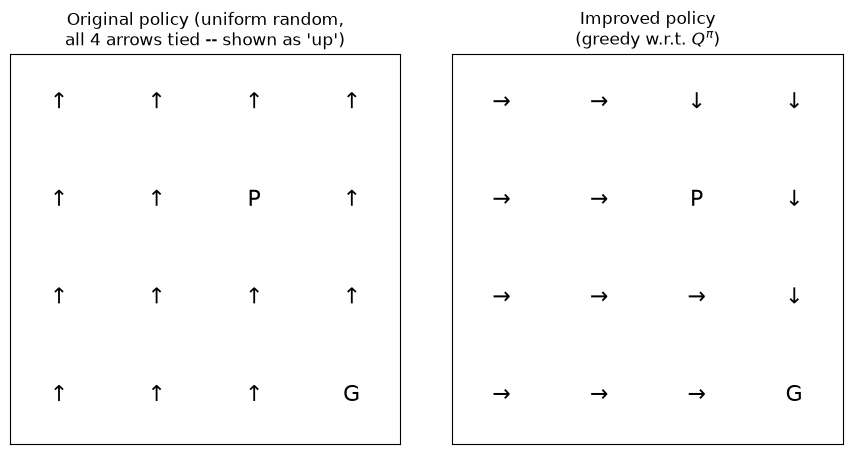

Note: this single improvement step is not yet guaranteed to be OPTIMAL --
just guaranteed to be no worse than what we started with. Optimality needs
us to alternate evaluation and improvement repeatedly, which is next.


In [5]:

def compute_Q_from_V(env, V, gamma):
    """Q(s,a) = one-step lookahead using the known model (this is exactly
    where the DP algorithms lean hard on 'we know P and R exactly')."""
    Q = {}
    for s in env.all_states:
        if env.is_terminal(s):
            Q[s] = {a: 0.0 for a in GridWorld.ACTIONS}
            continue
        Q[s] = {}
        for a in GridWorld.ACTIONS:
            s_next, reward, _ = env.step(s, a)
            Q[s][a] = reward + gamma * V[s_next]
    return Q

def greedy_policy_from_Q(Q):
    """pi'(s) = argmax_a Q(s,a), expressed as a deterministic policy_probs dict."""
    policy_probs = {}
    for s, qvals in Q.items():
        best_a = max(qvals, key=qvals.get)
        policy_probs[s] = {a: (1.0 if a == best_a else 0.0) for a in qvals}
    return policy_probs

Q_pi = compute_Q_from_V(env, V_pi, env.gamma)
greedy_pi = greedy_policy_from_Q(Q_pi)

fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
plot_policy_grid(env, uniform_probs, "Original policy (uniform random,\nall 4 arrows tied -- shown as 'up')", ax=axes[0])
plot_policy_grid(env, greedy_pi, "Improved policy\n(greedy w.r.t. $Q^\\pi$)", ax=axes[1])
plt.tight_layout()
plt.show()
print("Note: this single improvement step is not yet guaranteed to be OPTIMAL --")
print("just guaranteed to be no worse than what we started with. Optimality needs")
print("us to alternate evaluation and improvement repeatedly, which is next.")



## 4. Policy Iteration: alternate evaluation and improvement to convergence

The Policy Improvement Theorem gives us a strictly-non-decreasing sequence of
policies. **Policy Iteration** just keeps doing this until it stops changing:

1. **Evaluate**: compute $V^{\pi_k}$ exactly (iterative policy evaluation).
2. **Improve**: $\pi_{k+1}(s) = \arg\max_a Q^{\pi_k}(s,a)$.
3. If $\pi_{k+1} = \pi_k$, stop — we've reached a *fixed point of the
   improvement operator*, meaning no one-step deviation can do better, which
   (by the Bellman optimality equation from notebook 1) is exactly the
   definition of the **optimal policy** $\pi^*$. Otherwise go back to step 1.

Because the state space is finite, there are only finitely many possible
deterministic policies, and each iteration is guaranteed to be at least as good
as the last — so this process *must* terminate, in a finite number of steps,
at the exact optimum. No learning rate, no approximation, no luck involved.


Policy iteration converged in 3 outer (evaluate+improve) rounds,
using 175 total policy-evaluation sweeps.


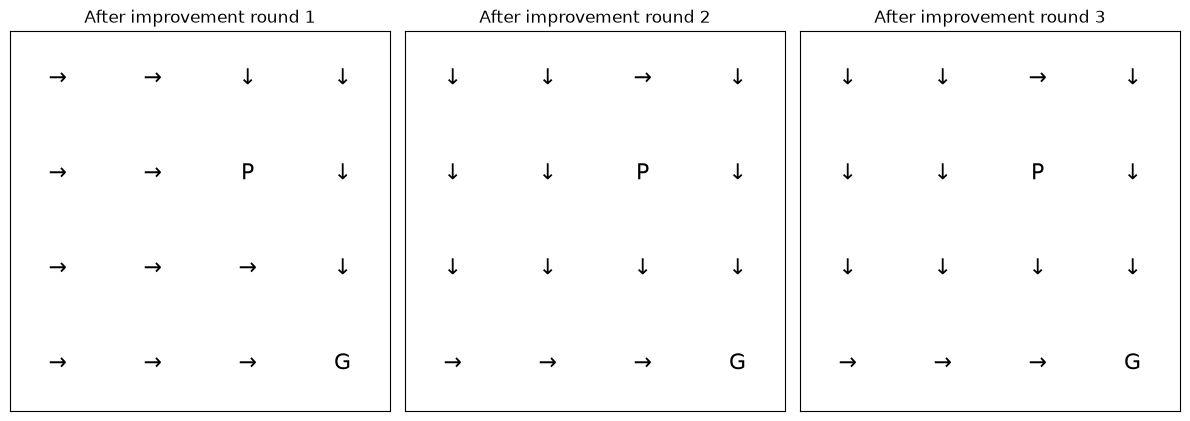

In [6]:

def policy_iteration(env, gamma, theta=1e-8, max_outer=1000):
    policy_probs = {s: {a: 0.25 for a in GridWorld.ACTIONS} for s in env.all_states}
    policy_snapshots = []
    total_eval_sweeps = 0
    for outer in range(max_outer):
        V, sweep_history = iterative_policy_evaluation(env, policy_probs, gamma, theta)
        total_eval_sweeps += len(sweep_history)
        Q = compute_Q_from_V(env, V, gamma)
        new_policy = greedy_policy_from_Q(Q)
        policy_snapshots.append(new_policy)
        if new_policy == policy_probs:
            return new_policy, V, policy_snapshots, total_eval_sweeps
        policy_probs = new_policy
    raise RuntimeError("policy iteration did not converge -- unexpected for a finite MDP")

pi_star_PI, V_star_PI, snapshots, total_sweeps_PI = policy_iteration(env, env.gamma)
print(f"Policy iteration converged in {len(snapshots)} outer (evaluate+improve) rounds,")
print(f"using {total_sweeps_PI} total policy-evaluation sweeps.")

n_show = len(snapshots)
fig, axes = plt.subplots(1, n_show, figsize=(4 * n_show, 4.5))
if n_show == 1:
    axes = [axes]
for i, snap in enumerate(snapshots):
    plot_policy_grid(env, snap, f"After improvement round {i+1}", ax=axes[i])
plt.tight_layout()
plt.show()



## 5. Value Iteration: merge evaluation and improvement into one sweep

Policy iteration's inner loop — fully evaluating $\pi_k$ until convergence
before even a single improvement step — is expensive. Do we really need to
evaluate a policy *exactly* before improving it? What if we improve after just
*one* sweep of evaluation?

Truncating policy evaluation to a single sweep, and immediately following it
with a greedy improvement, means the update becomes:

$$
V_{k+1}(s) = \max_a \sum_{s'} P(s'\mid s,a)\big[R(s,a,s') + \gamma V_k(s')\big]
$$

Look closely: this is *exactly* the Bellman **optimality** equation from
notebook 1, turned into an update rule the same way we turned the Bellman
*expectation* equation into iterative policy evaluation. We're directly
iterating the Bellman optimality operator $T^*$ (which has the same
contraction property as $T^\pi$, by an identical argument — $\max_a$ preserves
the contraction bound). **Value iteration never explicitly stores a policy
during the loop at all** — only at the very end do we extract $\pi^* =
\arg\max_a Q^*(s,a)$ from the converged $V^*$.


Value iteration converged in 7 sweeps (policy iteration needed 175 total evaluation sweeps across 3 rounds).
Max |V*_ValueIter - V*_PolicyIter| = 0.00e+00
Greedy actions agree at every non-terminal state: True


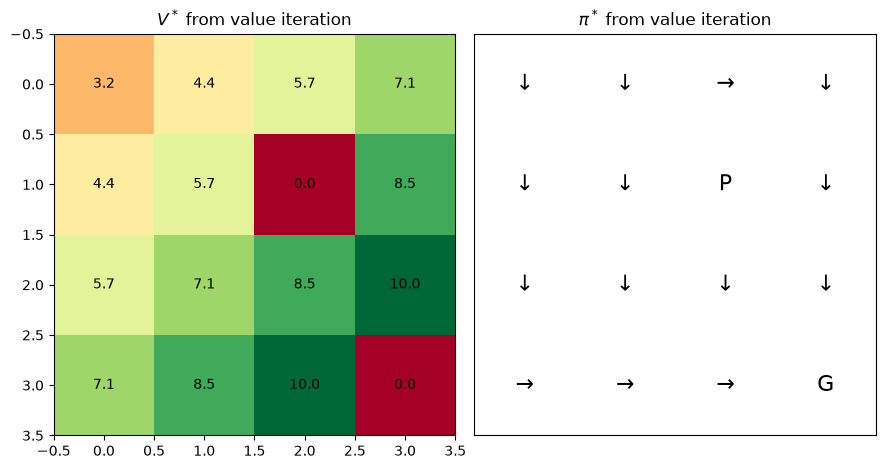

In [7]:

def value_iteration(env, gamma, theta=1e-8, max_sweeps=10000):
    V = {s: 0.0 for s in env.all_states}
    history = []
    for sweep in range(max_sweeps):
        delta = 0.0
        V_new = {}
        for s in env.all_states:
            if env.is_terminal(s):
                V_new[s] = 0.0
                continue
            q_values = []
            for a in GridWorld.ACTIONS:
                s_next, reward, _ = env.step(s, a)
                q_values.append(reward + gamma * V[s_next])
            V_new[s] = max(q_values)
            delta = max(delta, abs(V_new[s] - V[s]))
        V = V_new
        history.append(delta)
        if delta < theta:
            break
    Q = compute_Q_from_V(env, V, gamma)
    policy_probs = greedy_policy_from_Q(Q)
    return V, policy_probs, history

V_star_VI, pi_star_VI, vi_history = value_iteration(env, env.gamma)
print(f"Value iteration converged in {len(vi_history)} sweeps",
      f"(policy iteration needed {total_sweeps_PI} total evaluation sweeps "
      f"across {len(snapshots)} rounds).")

max_V_diff = max(abs(V_star_VI[s] - V_star_PI[s]) for s in env.all_states)
policies_agree = all(
    max(pi_star_VI[s], key=pi_star_VI[s].get) == max(pi_star_PI[s], key=pi_star_PI[s].get)
    for s in env.all_states if not env.is_terminal(s)
)
print(f"Max |V*_ValueIter - V*_PolicyIter| = {max_V_diff:.2e}")
print(f"Greedy actions agree at every non-terminal state: {policies_agree}")

fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
plot_value_grid(env, V_star_VI, "$V^*$ from value iteration", ax=axes[0])
plot_policy_grid(env, pi_star_VI, "$\\pi^*$ from value iteration", ax=axes[1])
plt.tight_layout()
plt.show()



Two independently-derived algorithms — one that fully evaluates each policy
before improving, one that never even materializes a policy until the very
end — land on the exact same $V^*$ and the exact same greedy policy. That
agreement is not a coincidence: both are just different iteration schedules
for solving the *same* underlying fixed-point equation (the Bellman optimality
equation), and that equation has a unique solution for a finite MDP with
$\gamma < 1$.



## 6. Generalized Policy Iteration: the idea that runs through the whole course

Step back and look at what both algorithms actually have in common. Policy
iteration alternates: fully evaluate, then fully improve, then fully evaluate
again. Value iteration interleaves them much more tightly: one partial
evaluation step, one partial improvement step, repeated. Sutton & Barto give
this family of algorithms a name: **Generalized Policy Iteration (GPI)** — any
process that maintains an (approximate) value function and an (approximate)
policy, and repeatedly:

- makes the value function **more consistent** with the current policy
  (evaluation), and
- makes the policy **greedier** with respect to the current value function
  (improvement),

will converge toward the point where both processes agree — which can only
happen at $V^*, \pi^*$, since that's the only place where "the value function
is consistent with the policy" and "the policy is greedy w.r.t. the value
function" are simultaneously true.

**Why we're spending a whole paragraph on this:** almost nothing in the rest of
this course is a fundamentally new idea. It's GPI, over and over, with two
things changing each time:

- **How is "evaluation" done?** Exact sweeps over a known model (this
  notebook) → sampling trajectories from an unknown environment (notebook 3,
  Monte Carlo & TD) → a neural network trained by gradient descent (notebook 4
  onward, including the critic inside PPO in notebook 6-7).
- **How is "improvement" done?** Exact $\arg\max$ over a small table (this
  notebook) → a gradient step that nudges action probabilities upward in
  proportion to their advantage (policy gradient methods, from notebook 5
  onward — including PPO, GRPO, and everything used to train modern LLMs).

Every time you see "PPO alternates between collecting rollouts and updating the
policy" later in this course, you should hear an echo of "policy iteration
alternates between evaluating $\pi_k$ and improving it to $\pi_{k+1}$." Same
skeleton, dramatically different (and much messier, much more approximate)
flesh.



## 7. Why doesn't this run directly on an LLM?

Everything in this notebook leaned on one assumption: **we know $P(s'\mid s,a)$
and $R(s,a,s')$ exactly, and we can afford to sweep over every state.** Neither
holds for LLM-scale problems, for two distinct reasons — worth separating them
clearly, since they fail in different ways:

1. **The state space is astronomically large.** Recall from notebook 1: a
   "state" is an entire prompt-plus-generation-so-far. With a vocabulary of
   size $|\mathcal{V}|$ (tens of thousands for a real tokenizer) and sequences
   up to length $L$, the number of possible states is on the order of
   $|\mathcal{V}|^L$ — a number so large that "loop over every state," the
   inner loop of every algorithm in this notebook, is not just slow, it is
   physically impossible. This alone rules out DP for LLMs, or for essentially
   any RL problem with a rich, high-dimensional, or continuous state space
   (robotics, Atari from pixels, and so on).
2. **The reward function usually isn't known in closed form either.** In
   RLHF (notebook 7), the reward comes from a learned reward model — itself a
   neural network we can only *evaluate* at specific completions, not write
   down as an explicit $R(s,a,s')$ table we could sum over. In RLVR (notebook
   8-9), reward comes from running a verifier (unit tests, a math checker) —
   again, something you can only *query*, not enumerate.

Both of these push toward the same conclusion: we need algorithms that learn
**by sampling** — generating some trajectories, observing their rewards, and
updating estimates from that limited experience — rather than by exhaustively
summing over everything the model could possibly do. That's precisely what
notebook 3 introduces: Monte Carlo and Temporal-Difference learning keep the
exact same evaluate/improve (GPI) skeleton from this notebook, but replace
"exact sum over a known model" with "average over samples from an unknown one."



## 8. Recap & exercises

**What we derived, from first principles:**

- Iterative policy evaluation, as repeated application of the Bellman
  expectation operator $T^\pi$, and *why* it converges (the $\gamma$-contraction
  argument) — verified both visually (geometric decay of the per-sweep delta)
  and numerically (agreement with notebook 1's exact linear-algebra solution).
- The Policy Improvement Theorem, derived via the "unrolling" substitution
  argument, not just quoted.
- Policy Iteration and Value Iteration, implemented from scratch, shown to
  converge to *the same* $V^*$ and $\pi^*$ despite being different iteration
  schedules of the same fixed-point equation.
- Generalized Policy Iteration as the unifying skeleton for essentially every
  algorithm still to come in this course.
- A precise account of exactly why DP can't be run on LLM-scale problems.

### Exercises

1. **Modified policy iteration.** Change `iterative_policy_evaluation`'s
   `max_sweeps` to a small fixed number (say, 3) instead of running to full
   convergence inside `policy_iteration`. Does it still converge to the same
   $\pi^*$? How does the total number of evaluation sweeps compare to full
   policy iteration and to value iteration? (You've just implemented the
   general algorithm that both policy iteration and value iteration are special
   cases of.)
2. **Stochastic transitions.** Add a "slip" probability: with probability 0.1
   the agent moves in a random direction instead of the intended one. Update
   `env.step` to be stochastic, and adapt `compute_Q_from_V` to average over
   the possible outcomes (you'll need $P(s'\mid s,a)$ explicitly now, not just
   the single deterministic next state). Does the optimal policy route further
   away from the pit than before? Why would that make sense?
3. **Bigger grid.** Scale the grid to 10x10 with a few pits. Time how long
   value iteration takes to converge as a function of grid size, and think
   about how that scaling relates to Section 7's argument about why DP breaks
   down for LLMs.
